# - Neural Machine Translation by Jointly Learning to Align and Translate




## Setup

In [1]:
!pip install torch==2.4.1 --index-url https://download.pytorch.org/whl/cu118
!pip install pytorch-lightning==2.2.4
!pip install torchmetrics
!pip install sacrebleu
!pip install sentencepiece
!pip install datasets
!pip install spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

Looking in indexes: https://download.pytorch.org/whl/cu118
     ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.7 GB 55.5 MB/s eta 0:00:49
     ---------------------------------------- 0.0/2.7 GB 60.7 MB/s eta 0:00:45
      --------------------------------------- 0.0/2.7 GB 54.9 MB/s eta 0:00:49
      --------------------------------------- 0.0/2.7 GB 60.3 MB/s eta 0:00:44
      --------------------------------------- 0.1/2.7 GB 63.1 MB/s eta 0:00:42
     - -------------------------------------- 0.1/2.7 GB 67.6 MB/s eta 0:00:39
     - -------------------------------------- 0.1/2.7 GB 67.6 MB/s eta 0:00:39
     - -------------------------------------- 0.1/2.7 GB 69.3 MB/s eta 0:00:38
     - -------------------------------------- 0.1/2.7 GB 71.9 MB/s eta 0:00:36
     -- ------------------------------------- 0.2/2.7 GB 74.1 MB/s eta 0:00:35
     -- ------------------------------------- 0.2/2.7 GB 74.9 MB/s eta 0:00:34
 

## Imports

In [7]:
!pip install -q --upgrade tqdm datasets

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset

import spacy
import numpy as np

import random
import math
import time
from collections import Counter


## Reproducibility

In [10]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

## Preparing Data

We load the Multi30k dataset via HuggingFace `datasets` instead of `torchtext.legacy`.
We then build vocabularies manually and create PyTorch DataLoaders with padding.


In [28]:
# Read the text file
def extract_sent(f_path):
    with open(f_path, "r", encoding="utf-8") as f:
        lines = f.read().splitlines()
        return lines

In [29]:
import os
src = r"C:\Users\Jishnu_major\Desktop\iitd_assign\hin_mr"
mr_train = extract_sent(os.path.join(src, "train_mr.txt"))
mr_test = extract_sent(os.path.join(src, "test_mr.txt"))
hi_train = extract_sent(os.path.join(src, "train_hi.txt"))
hi_test = extract_sent(os.path.join(src, "test_hi.txt"))

In [30]:
print(hi_train[0])
print(mr_train[0])

print(len(hi_train))
print(len(mr_train))


print(len(hi_test))
print(len(mr_test))

इस  प्रयोग  को  नित्य  करने  से  दाँत  नहीं  सड़ते  । 
हा  प्रयोग  रोज  केल्याने  दात  खराब  होत  नाही  . 
241847
241847
10390
10390


In [ ]:

#     return [tok.text.lower() for tok in spacy_mr.tokenizer(text)]

In [117]:
import sentencepiece as spm

# Train SentencePiece on your raw text files
# 8000 vocab size is good for Hindi/Marathi — tune as needed
spm.SentencePieceTrainer.train(
    input=r"C:\Users\Jishnu_major\Desktop\iitd_assign\hin_mr\train_hi.txt",
    model_prefix="spm_hi",
    vocab_size=30000,
    character_coverage=0.9995,  # high coverage for Devanagari script
    model_type="bpe"
)

spm.SentencePieceTrainer.train(
    input=r"C:\Users\Jishnu_major\Desktop\iitd_assign\hin_mr\train_mr.txt",
    model_prefix="spm_mr",
    vocab_size=30000,
    character_coverage=0.9995,
    model_type="bpe"
)

sp_hi = spm.SentencePieceProcessor(model_file="spm_hi.model")
sp_mr = spm.SentencePieceProcessor(model_file="spm_mr.model")

def tokenize_hi(text):
    return sp_hi.encode(text, out_type=str)

def tokenize_mr(text):
    return sp_mr.encode(text, out_type=str)

In [ ]:
# Build vocabulary from scratch 
class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.itos = ['<unk>', '<pad>', '<sos>', '<eos>']
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def build(self, tokenized_sentences):
        counter = Counter(tok for sent in tokenized_sentences for tok in sent)
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.stoi[word] = len(self.itos)
                self.itos.append(word)
        return self

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi['<unk>']) for t in tokens]

# Tokenize once
hi_train_1 = [tokenize_hi(ex) for ex in hi_train]
mr_train_1 = [tokenize_mr(ex) for ex in mr_train]

SRC_VOCAB = Vocabulary(min_freq=2).build(hi_train_1)
TRG_VOCAB = Vocabulary(min_freq=2).build(mr_train_1)

print(f"SRC vocab size: {len(SRC_VOCAB):,}")
print(f"TRG vocab size: {len(TRG_VOCAB):,}")

SRC vocab size: 28,565
TRG vocab size: 29,982


In [119]:
SRC_VOCAB

In [120]:
import pandas as pd
df = pd.DataFrame()
df['hi'] = hi_train
df['mr'] = mr_train

In [121]:
df_train = df[:200000][:].reset_index(drop=True)

In [122]:
df_val = df[200000:][:].reset_index(drop=True)

In [123]:
df_val

,hi,mr
0,इस प्रकार नबियों के विषय में सेनाओं का यहुवाह ...,सर्वशक्तिमान परमेश्वर संदेष्ट्यांबद्दल म्हणतो ...
1,"इस प्रकार आर्मिस के याहवे कहते हैं, भविष्यद्वक...",सर्वशक्तिमान परमेश्वर ह्या गोष्टी सांगतो : “ ह...
2,वे उन लोगों से लगातार कहते हैं जो मुझे घृणा कर...,काही लोक परमेश्वराकडून आलेल्या खऱ्या संदेशाला ...
3,"यहुवे की परिषद में कौन खड़ा है, कि उसे अपना वच...",पण ह्या संदेष्ट्यांमधील कोणीही स्वर्गातील देवा...
4,"देखो, याह्वेह का तूफान, उसका क्रोध आगे बढ़ गया...",आता परमेश्वराकडून वादळाप्रमाणे शिक्षा येईल . प...
...,...,...
41842,"और आत्मा और दुल्हन कहते हैं, आओ। और सुनने वाला...","आत्मा आणि नवरी असे म्हणतात की , “ ये ! आणि जो ..."
41843,"क्योंकि मैं हर उस आदमी की गवाही देता हूं, जो इ...",या पुस्तकात भविष्याकाळाबाबत नमूद केलेली वचने ज...
41844,और यदि कोई व्यक्ति इस भविष्यवाणी की पुस्तक के ...,आणि जो कोणी भविष्याकाळाबाबत संदेश देणाऱ्या या ...
41845,"वह जो इन बातों को स्पष्ट करता है, निश्चित रूप ...","जो येशू या गोष्टीविषयी साक्ष देतो , तो म्हणतो ..."


In [124]:
import pandas as pd
df_test = pd.DataFrame()
df_test['hi'] = hi_test
df_test['mr'] = mr_test

In [125]:
df_test

,hi,mr
0,यदि श्वास प्रणालिका में सूजन आ जाये तब ...,जर श्वासनलिकेला सूज आली तरीही रक्त तोंडावाटे ब...
1,यदि कान में पड़ी हुई चीज़ को तुरंत सूज...,जर कानात पडलेल्या वस्तुला लगेच सूज इत्यादीमुळे...
2,नाश्ता नहीं करने पर आपका उपापचय दोपहर के भोजन ...,नाश्ता केल्यानंतर तुमचा उपापचय दुपारच्या जेवणा...
3,राजस्थान की पहली महिला पायलट नम्रता भट्ट...,राजस्थानची पहिली स्त्री पायलट नम्रता भट...
4,प्रजनन एवं बाल स्वास्थ्य कार्यक्रम के अन...,प्रजनन आणि बाल आरोग्य योजनेअंतर्गत महिला ...
...,...,...
10385,"जब वे रेफ़िडिम से चले गए थे, और सिनाई के जंगल ...",ते लोक रफीदीम सोडून सीनायच्या रानात आले होते ;...
10386,"मूसा भगवान के पास गया, और यहुव ने उसे पहाड़ से...",मग मोशे पर्वतावर देवाला भेटावयास गेला तो पर्वत...
10387,&#39;तुमने देखा कि मैंने मिस्रियों के साथ क्या...,‘ मी माझ्या शत्रुंचे काय करतो ते तुम्ही पाहिले...
10388,"अब इसलिए, यदि तुम मेरी वाणी का वास्तव में पालन...",म्हणून मी आता तुम्हाला सांगतो की तुम्ही माझ्या...


In [126]:
# Dataset & DataLoader (replaces BucketIterator)
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, src_vocab, trg_vocab, tokenize_src, tokenize_trg):
        self.data = hf_dataset
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.tokenize_src = tokenize_src
        self.tokenize_trg = tokenize_trg

    def __len__(self):
        return len(self.data)

    # def __getitem__(self, idx):
    #     src_tokens = ['<sos>'] + self.tokenize_src(self.data[idx]['hi']) + ['<eos>']
    #     trg_tokens = ['<sos>'] + self.tokenize_trg(self.data[idx]['mr']) + ['<eos>']
    #     src_ids = torch.tensor(self.src_vocab.encode(src_tokens), dtype=torch.long)
    #     trg_ids = torch.tensor(self.trg_vocab.encode(trg_tokens), dtype=torch.long)
    #     return src_ids, trg_ids
    def __getitem__(self, idx):
        # Use .iloc[idx] instead of [idx] for pandas DataFrame row access
        row = self.data.iloc[idx]
        src_tokens = ['<sos>'] + self.tokenize_src(row['hi']) + ['<eos>']
        trg_tokens = ['<sos>'] + self.tokenize_trg(row['mr']) + ['<eos>']
        src_ids = torch.tensor(self.src_vocab.encode(src_tokens), dtype=torch.long)
        trg_ids = torch.tensor(self.trg_vocab.encode(trg_tokens), dtype=torch.long)
        return src_ids, trg_ids

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    # Pad and transpose to [seq_len, batch_size] to match original code
    src_padded = pad_sequence(src_batch, padding_value=SRC_VOCAB.stoi['<pad>']).long()
    trg_padded = pad_sequence(trg_batch, padding_value=TRG_VOCAB.stoi['<pad>']).long()
    return src_padded, trg_padded

BATCH_SIZE = 16
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

train_dataset = TranslationDataset(df_train, SRC_VOCAB, TRG_VOCAB, tokenize_hi, tokenize_mr)
valid_dataset = TranslationDataset(df_val, SRC_VOCAB, TRG_VOCAB, tokenize_hi, tokenize_mr)
test_dataset  = TranslationDataset(df_test,  SRC_VOCAB, TRG_VOCAB, tokenize_hi, tokenize_mr)

train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
valid_iterator = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_iterator  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_iterator)} | Valid batches: {len(valid_iterator)}")

Device: cuda
Train batches: 12500 | Valid batches: 2616


## Building the Seq2Seq Model

Four components:
1. **Encoder** — Bidirectional LSTM
2. **Attention** — alignment model
3. **Decoder** — LSTM with attention
4. **Seq2Seq** — ties them together


### Encoder

In [127]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, enc_hid_dim, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src len, batch size, emb dim]
        # outputs, hidden = self.rnn(embedded)
        outputs, (hidden, cell) = self.rnn(embedded)
        # outputs = [src len, batch size, hid dim * 2]
        # hidden  = [2, batch size, hid dim]
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        # hidden = [batch size, dec hid dim]
        return outputs, hidden

### Attention

In [128]:
class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v    = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden          = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_len    = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden          = [batch size, src len, dec hid dim]
        # encoder_outputs = [batch size, src len, enc hid dim * 2]

        energy    = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        # attention = [batch size, src len]
        return F.softmax(attention, dim=1)

### Decoder

In [129]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention  = attention
        self.embedding  = nn.Embedding(output_dim, emb_dim)
        self.rnn        = nn.LSTM((enc_hid_dim * 2) + emb_dim, dec_hid_dim)
        self.fc_out     = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input           = [batch size]
        # hidden          = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]
        input    = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, emb dim]

        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        # a = [batch size, 1, src len]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted        = torch.bmm(a, encoder_outputs).permute(1, 0, 2)
        # weighted = [1, batch size, enc hid dim * 2]

        rnn_input        = torch.cat((embedded, weighted), dim=2)
        # output, hidden   = self.rnn(rnn_input, hidden.unsqueeze(0))
        output, (hidden, _)  = self.rnn(rnn_input, (hidden.unsqueeze(0), torch.zeros_like(hidden.unsqueeze(0))))

        # output = [1, batch size, dec hid dim]
        # hidden = [1, batch size, dec hid dim]
        # assert (output == hidden).all()

        embedded = embedded.squeeze(0)
        output   = output.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0)

### Seq2Seq

In [130]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src len, batch size]
        # trg = [trg len, batch size]
        batch_size     = src.shape[1]
        trg_len        = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)

        input = trg[0, :]  # <sos> token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden, encoder_outputs)
            outputs[t]     = output
            teacher_force  = random.random() < teacher_forcing_ratio
            top1           = output.argmax(1)
            input          = trg[t] if teacher_force else top1

        return outputs

## Training the Model

In [131]:
INPUT_DIM   = len(SRC_VOCAB)
OUTPUT_DIM  = len(TRG_VOCAB)
ENC_EMB_DIM = 256//2
DEC_EMB_DIM = 256//2
ENC_HID_DIM = 512//2
DEC_HID_DIM = 512//2
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.2

attn  = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc   = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
dec   = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, device).to(device)

In [132]:
def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 36,426,398 trainable parameters


In [133]:
optimizer = optim.Adam(model.parameters())

In [134]:
# <pad> index is 1 in our vocab — matches TRG_VOCAB.stoi['<pad>']
TRG_PAD_IDX = TRG_VOCAB.stoi['<pad>']
criterion   = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

# new code train

In [ ]:
import sacrebleu
from tqdm import tqdm

#: helpers :

def get_loss(model, src, trg, criterion, teacher_forcing=0.5):
    output     = model(src, trg, teacher_forcing)
    output_dim = output.shape[-1]
    output     = output[1:].view(-1, output_dim)
    trg        = trg[1:].view(-1)
    return criterion(output, trg)

def decode_batch(model, src, trg_vocab, max_len=50):
    """Greedy decode a batch, return list of token-string lists."""
    model.eval()
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)
        batch_size  = src.shape[1]
        input_token = torch.tensor([trg_vocab.stoi['<sos>']] * batch_size, device=src.device)
        translations = [[] for _ in range(batch_size)]
        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden, encoder_outputs)
            top1 = output.argmax(1)
            for b in range(batch_size):
                tok = trg_vocab.itos[top1[b].item()]
                translations[b].append(tok)
            input_token = top1
        # strip everything from <eos> onward
        results = []
        for toks in translations:
            clean = []
            for t in toks:
                if t == '<eos>': break
                # if t not in ('<unk>', '<pad>', '<sos>'):
                if t not in ('<unk>', '<pad>', '<sos>', '<eos>'):
                    clean.append(t)
            results.append(clean)
        return results

def compute_metrics(model, iterator, criterion, n_batches=50, device='cpu'):
    """Evaluate loss + BLEU + chrF++ over n_batches batches."""
    model.eval()
    total_loss = 0
    hyps, refs = [], []

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            if i >= n_batches: break
            src = src.to(device)
            trg = trg.to(device)
            loss = get_loss(model, src, trg, criterion, teacher_forcing=0)
            total_loss += loss.item()
            preds = decode_batch(model, src, TRG_VOCAB)
            for b in range(trg.shape[1]):
                ref_toks = [TRG_VOCAB.itos[t.item()] for t in trg[1:, b]
                            if TRG_VOCAB.itos[t.item()] not in ('<eos>','<pad>')]
                # hyps.append(' '.join(preds[b]))
                # refs.append(' '.join(ref_toks))
                hyps.append(sp_mr.decode(preds[b]))
                refs.append(sp_mr.decode(ref_toks))

    avg_loss = total_loss / min(n_batches, i+1)
    bleu  = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf  = sacrebleu.corpus_chrf(hyps, [refs], beta=2).score   # chrF++
    return avg_loss, bleu, chrf


In [ ]:
#  step-level training loop 
# Every EVAL_EVERY train steps → run 1 val batch for loss,
# Every METRIC_EVERY train steps → run n_batches for BLEU+chrF++

TRAIN_STEPS   = 12500   # total training batches to run (= 1 full epoch)
EVAL_EVERY    = 5       # eval loss every N train steps
METRIC_EVERY  = 250*2     # compute BLEU+chrF++ every N train steps (heavier)
VAL_LOSS_BATCHES   = 1  # val batches per quick loss check
VAL_METRIC_BATCHES = 25 # val batches per BLEU/chrF++ computation
CLIP = 1

# Storage
train_loss_steps,  val_loss_steps   = [], []
train_bleu_steps,  val_bleu_steps   = [], []
train_chrf_steps,  val_chrf_steps   = [], []
loss_x, metric_x = [], []   # x-axis step indices

best_val_loss = float('inf')
val_iter_cycle = iter(valid_iterator)   # cycle through val batches

model.train()
train_iter = iter(train_iterator)
step = 0

print(f"Training for {TRAIN_STEPS} steps | eval every {EVAL_EVERY} | metrics every {METRIC_EVERY}")

for step in tqdm(range(1, TRAIN_STEPS + 1)):

    #  train one batch 
    try:
        src, trg = next(train_iter)
    except StopIteration:
        train_iter = iter(train_iterator)
        src, trg = next(train_iter)

    src, trg = src.to(device), trg.to(device)
    optimizer.zero_grad()
    loss = get_loss(model, src, trg, criterion, teacher_forcing=0.5)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()


    if step % EVAL_EVERY == 0:
        t_loss = loss.item()

        # 1 val batch for quick val loss
        try:
            vsrc, vtrg = next(val_iter_cycle)
        except StopIteration:
            val_iter_cycle = iter(valid_iterator)
            vsrc, vtrg = next(val_iter_cycle)

        model.eval()
        with torch.no_grad():
            v_loss = get_loss(model, vsrc.to(device), vtrg.to(device), criterion, teacher_forcing=0).item()
        model.train()

        train_loss_steps.append(t_loss)
        val_loss_steps.append(v_loss)
        loss_x.append(step)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), 'tuta-model.pt')

    
    if step % METRIC_EVERY == 0:
        t_loss_m, t_bleu, t_chrf = compute_metrics(
            model, train_iterator, criterion, VAL_METRIC_BATCHES, device)
        v_loss_m, v_bleu, v_chrf = compute_metrics(
            model, valid_iterator, criterion, VAL_METRIC_BATCHES, device)

        train_bleu_steps.append(t_bleu);  val_bleu_steps.append(v_bleu)
        train_chrf_steps.append(t_chrf);  val_chrf_steps.append(v_chrf)
        metric_x.append(step)

        print(f"Step {step:>6} | "
              f"T-Loss {t_loss_m:.3f} V-Loss {v_loss_m:.3f} | "
              f"T-BLEU {t_bleu:.2f} V-BLEU {v_bleu:.2f} | "
              f"T-chrF++ {t_chrf:.2f} V-chrF++ {v_chrf:.2f}")
        model.train()

print("Training complete.")


Training for 12500 steps | eval every 5 | metrics every 500


  4%|▍         | 499/12500 [38:13<24:32:56,  7.36s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
  4%|▍         | 500/12500 [39:43<106:58:17, 32.09s/it]

Step    500 | T-Loss 7.096 V-Loss 7.283 | T-BLEU 2.23 V-BLEU 0.36 | T-chrF++ 12.03 V-chrF++ 4.65


  8%|▊         | 999/12500 [1:17:38<15:42:18,  4.92s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
  8%|▊         | 1000/12500 [1:19:06<96:07:28, 30.09s/it]

Step   1000 | T-Loss 7.005 V-Loss 7.251 | T-BLEU 2.06 V-BLEU 0.41 | T-chrF++ 12.03 V-chrF++ 4.43


...

Step  11500 | T-Loss 6.526 V-Loss 7.008 | T-BLEU 4.42 V-BLEU 1.12 | T-chrF++ 20.84 V-chrF++ 8.69


 96%|█████████▌| 11999/12500 [12:49:26<24:58,  2.99s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
 96%|█████████▌| 12000/12500 [12:50:54<3:57:20, 28.48s/it]

Step  12000 | T-Loss 6.403 V-Loss 7.030 | T-BLEU 4.52 V-BLEU 1.07 | T-chrF++ 21.60 V-chrF++ 9.97


100%|█████████▉| 12499/12500 [13:19:15<00:05,  5.96s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
100%|██████████| 12500/12500 [13:20:38<00:00,  3.84s/it]

Step  12500 | T-Loss 6.261 V-Loss 7.031 | T-BLEU 4.31 V-BLEU 1.44 | T-chrF++ 21.57 V-chrF++ 10.71
Training complete.


In [ ]:
# Epoch 2: continues from existing model + lists
TRAIN_STEPS_E2     = 12500
STEP_OFFSET        = loss_x[-1] if loss_x else 0   # continues x-axis from epoch 1 end
METRIC_OFFSET      = metric_x[-1] if metric_x else 0

val_iter_cycle2 = iter(valid_iterator)
train_iter2     = iter(train_iterator)

# Load best checkpoint from epoch 1 to continue from best weights
model.load_state_dict(torch.load('tuta-model.pt'))
model.train()

print(f"Resuming from step {STEP_OFFSET} | Training {TRAIN_STEPS_E2} more steps")

for step in tqdm(range(1, TRAIN_STEPS_E2 + 1), mininterval=30):
    global_step = STEP_OFFSET + step   # x-axis continues from epoch 1

    #  train one batch 
    try:
        src, trg = next(train_iter2)
    except StopIteration:
        train_iter2 = iter(train_iterator)
        src, trg = next(train_iter2)

    src, trg = src.to(device), trg.to(device)
    optimizer.zero_grad()
    loss = get_loss(model, src, trg, criterion, teacher_forcing=0.5)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()

    #  quick loss eval every EVAL_EVERY steps 
    if step % EVAL_EVERY == 0:
        t_loss = loss.item()

        try:
            vsrc, vtrg = next(val_iter_cycle2)
        except StopIteration:
            val_iter_cycle2 = iter(valid_iterator)
            vsrc, vtrg = next(val_iter_cycle2)

        model.eval()
        with torch.no_grad():
            v_loss = get_loss(model, vsrc.to(device), vtrg.to(device), criterion, teacher_forcing=0).item()
        model.train()

        #  append to existing lists
        train_loss_steps.append(t_loss)
        val_loss_steps.append(v_loss)
        loss_x.append(global_step)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), 'tuta-model.pt')

    #  full metrics every METRIC_EVERY steps 
    if step % METRIC_EVERY == 0:
        t_loss_m, t_bleu, t_chrf = compute_metrics(
            model, train_iterator, criterion, VAL_METRIC_BATCHES, device)
        v_loss_m, v_bleu, v_chrf = compute_metrics(
            model, valid_iterator, criterion, VAL_METRIC_BATCHES, device)

        train_bleu_steps.append(t_bleu);  val_bleu_steps.append(v_bleu)
        train_chrf_steps.append(t_chrf);  val_chrf_steps.append(v_chrf)
        metric_x.append(global_step)    # ← offset x so plots stay continuous

        print(f"Step {global_step:>6} | "
              f"T-Loss {t_loss_m:.3f} V-Loss {v_loss_m:.3f} | "
              f"T-BLEU {t_bleu:.2f} V-BLEU {v_bleu:.2f} | "
              f"T-chrF++ {t_chrf:.2f} V-chrF++ {v_chrf:.2f}")
        model.train()

print("Epoch 2 complete.")

C:\Users\Jishnu_major\AppData\Local\Temp\ipykernel_29980\1586656541.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('tuta-model.pt'))


Resuming from step 12515 | Training 12500 more steps


  4%|▍         | 499/12500 [33:24<12:38:30,  3.79s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
  4%|▍         | 500/12500 [34:42<26:18:40,  7.89s/it]

Step  13015 | T-Loss 6.571 V-Loss 7.096 | T-BLEU 4.32 V-BLEU 0.90 | T-chrF++ 20.39 V-chrF++ 8.95


  8%|▊         | 995/12500 [1:06:06<13:15:36,  4.15s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
  8%|▊         | 1000/12500 [1:07:32<24:10:22,  7.57s/it]

...

Step  24015 | T-Loss 6.220 V-Loss 7.016 | T-BLEU 6.35 V-BLEU 1.58 | T-chrF++ 26.23 V-chrF++ 13.63


 96%|█████████▌| 11999/12500 [13:38:47<38:12,  4.58s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
 96%|█████████▌| 12000/12500 [13:40:06<1:19:18,  9.52s/it]

Step  24515 | T-Loss 6.245 V-Loss 6.940 | T-BLEU 6.32 V-BLEU 1.66 | T-chrF++ 25.35 V-chrF++ 11.69


100%|█████████▉| 12498/12500 [14:14:49<00:08,  4.32s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
100%|██████████| 12500/12500 [14:16:06<00:00,  4.11s/it]

Step  25015 | T-Loss 6.141 V-Loss 6.975 | T-BLEU 6.66 V-BLEU 1.22 | T-chrF++ 26.81 V-chrF++ 11.74
Epoch 2 complete.


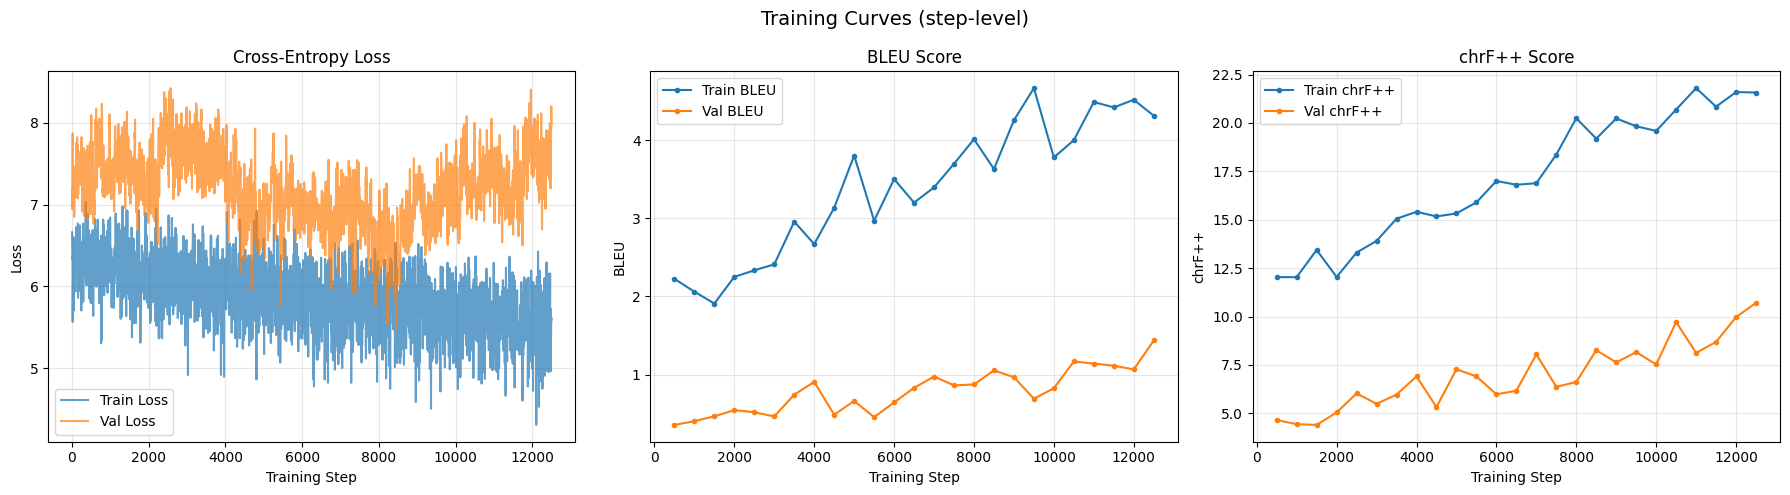

Plot saved to training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves (step-level)', fontsize=14)

# ── Loss :──────
axes[0].plot(loss_x, train_loss_steps, label='Train Loss', alpha=0.7)
axes[0].plot(loss_x, val_loss_steps,   label='Val Loss',   alpha=0.7)
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── BLEU :──────
axes[1].plot(metric_x, train_bleu_steps, label='Train BLEU', marker='o', markersize=3)
axes[1].plot(metric_x, val_bleu_steps,   label='Val BLEU',   marker='o', markersize=3)
axes[1].set_title('BLEU Score')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('BLEU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── chrF++ ───────────────────────────────────────────────────────────────
axes[2].plot(metric_x, train_chrf_steps, label='Train chrF++', marker='o', markersize=3)
axes[2].plot(metric_x, val_chrf_steps,   label='Val chrF++',   marker='o', markersize=3)
axes[2].set_title('chrF++ Score')
axes[2].set_xlabel('Training Step')
axes[2].set_ylabel('chrF++')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=1500, bbox_inches='tight')
plt.show()
print("Plot saved to training_curves.png")


In [153]:
import pickle

data = {
    "train_loss_steps": train_loss_steps,
    "val_loss_steps": val_loss_steps,
    "train_bleu_steps": train_bleu_steps,
    "val_bleu_steps": val_bleu_steps,
    "train_chrf_steps": train_chrf_steps,
    "val_chrf_steps": val_chrf_steps,
    "loss_x": loss_x,
    "metric_x": metric_x
}

# Save
with open("metrics_1.pkl", "wb") as f:
    pickle.dump(data, f)

In [ ]:
#  Final test evaluation 
model.load_state_dict(torch.load('tuta-model.pt'))
test_loss, test_bleu, test_chrf = compute_metrics(
    model, test_iterator, criterion, n_batches=100, device=device)

print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')
print(f'| Test BLEU: {test_bleu:.2f} | Test chrF++: {test_chrf:.2f} |')


C:\Users\Jishnu_major\AppData\Local\Temp\ipykernel_29980\2710822473.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('tuta-model.pt'))
Th

| Test Loss: 6.122 | Test PPL: 455.630 |
| Test BLEU: 3.96 | Test chrF++: 25.36 |


In [152]:
model.load_state_dict(torch.load('tuta-model.pt'))
test_loss = evaluate(model, test_iterator, criterion)
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')

C:\Users\Jishnu_major\AppData\Local\Temp\ipykernel_29980\947942910.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('tuta-model.pt'))


| Test Loss: 6.608 | Test PPL: 741.045 |


# Past Code

In [135]:
from tqdm import tqdm
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for i, (src, trg) in tqdm(enumerate(iterator)):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        # output = [trg len, batch size, output dim]
        # trg    = [trg len, batch size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg    = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [136]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            src = src.to(device)
            trg = trg.to(device)

            output     = model(src, trg, 0)  # no teacher forcing
            output_dim = output.shape[-1]
            output     = output[1:].view(-1, output_dim)
            trg        = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [137]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [138]:
N_EPOCHS = 2
CLIP     = 1

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tuta-model.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

5888it [6:34:17,  4.02s/it]


KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load('tuta-model.pt'))
test_loss = evaluate(model, test_iterator, criterion)
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')